# Initial modelling

Rough structure for modelling notebook.

## 1. Load modelling dataset

In [12]:
# Add imports and load the agreed modelling dataset here.
# Check the column names against the data dictionary.
# Confirm the timestamp time zone and keep NSW observations.

import pandas as pd
import matplotlib.pyplot as plt


# Read the CSV, convert the timestamp and keep NSW rows.
def load_data(file_path):
    data = pd.read_csv(file_path)
    data['INTERVAL_DATETIME'] = pd.to_datetime(data['INTERVAL_DATETIME'])
    data = data[data['REGIONID'] == 'NSW1'].copy()
    return data.sort_values('INTERVAL_DATETIME')


data = load_data('sample_data.csv')
data.head()

,INTERVAL_DATETIME,REGIONID,OPERATIONAL_DEMAND_MW,OPERATIONAL_DEMAND_ADJUSTMENT_MW,WDR_ESTIMATE_MW,ROOFTOP_PV_POWER_MW,PV_QUALITY_INDICATOR,TEMPERATURE_C,CLOUD_COVER_PERCENT,SOLAR_EXPOSURE_30MIN_MJ_M2
0,2026-01-01 00:00:00+10:00,NSW1,6609.5,0.0,0.0,0.0,1.0,21.4,80.3,0.0
1,2026-01-01 00:30:00+10:00,NSW1,6765.7,0.0,0.0,0.0,1.0,21.1,75.4,0.0
2,2026-01-01 01:00:00+10:00,NSW1,6734.7,0.0,0.0,0.0,1.0,20.4,79.5,0.0
3,2026-01-01 01:30:00+10:00,NSW1,6739.4,0.0,0.0,0.0,1.0,20.2,89.4,0.0
4,2026-01-01 02:00:00+10:00,NSW1,6780.6,0.0,0.0,0.0,1.0,21.3,61.7,0.0


## 2. Sanity checks

In [13]:
# Check date coverage, duplicate timestamps, missing values and quality flags.
# Check that intervals are half-hourly and demand/PV are in MW.

# Calculate demand and PV changes from the previous half-hour.
# Add calendar fields and PV-change lags without bridging missing intervals.

# Choose chronological training, validation and test periods.
# Keep the final test period aside until the modelling choices are settled.


# Print a few simple checks before using the data.
def check_data(data):
    print('Date range:', data['INTERVAL_DATETIME'].min(), 'to', data['INTERVAL_DATETIME'].max())
    print('Rows:', len(data))
    print('Duplicate timestamps:', data['INTERVAL_DATETIME'].duplicated().sum())
    print('Missing values by column:')
    print(data.isna().sum())
    print('PV quality flags:')
    print(data['PV_QUALITY_INDICATOR'].value_counts(dropna=False))

    time_gaps = data['INTERVAL_DATETIME'].diff().dropna()
    print('All intervals are 30 minutes:', (time_gaps == pd.Timedelta(minutes=30)).all())
    print(data[['OPERATIONAL_DEMAND_MW', 'ROOFTOP_PV_POWER_MW']].describe())


# Calculate changes here rather than storing them in the CSV.
def add_changes(data):
    data = data.sort_values('INTERVAL_DATETIME').copy()

    # Resolve missing or duplicate timestamps before calculating changes.
    if data['INTERVAL_DATETIME'].isna().any():
        raise ValueError('Check missing timestamps before calculating changes.')
    if data['INTERVAL_DATETIME'].duplicated().any():
        raise ValueError('Check duplicate timestamps before calculating changes.')

    # Only compare rows that are exactly half an hour apart.
    time_gaps = data['INTERVAL_DATETIME'].diff()
    half_hour_apart = time_gaps == pd.Timedelta(minutes=30)
    data['DEMAND_CHANGE_MW'] = data['OPERATIONAL_DEMAND_MW'].diff().where(half_hour_apart)
    data['PV_CHANGE_MW'] = data['ROOFTOP_PV_POWER_MW'].diff().where(half_hour_apart)
    return data


check_data(data)
data = add_changes(data)

Date range: 2026-01-01 00:00:00+10:00 to 2026-12-31 23:30:00+10:00
Rows: 17520
Duplicate timestamps: 0
Missing values by column:
INTERVAL_DATETIME                   0
REGIONID                            0
OPERATIONAL_DEMAND_MW               0
OPERATIONAL_DEMAND_ADJUSTMENT_MW    0
WDR_ESTIMATE_MW                     0
ROOFTOP_PV_POWER_MW                 0
PV_QUALITY_INDICATOR                0
TEMPERATURE_C                       0
CLOUD_COVER_PERCENT                 0
SOLAR_EXPOSURE_30MIN_MJ_M2          0
dtype: int64
PV quality flags:
PV_QUALITY_INDICATOR
1.0    17520
Name: count, dtype: int64
All intervals are 30 minutes: True
       OPERATIONAL_DEMAND_MW  ROOFTOP_PV_POWER_MW
count           17520.000000         17520.000000
mean             7464.501478           409.363779
std               644.678923           506.798523
min              5713.800000             0.000000
25%              6965.675000             0.000000
50%              7367.300000             0.000000
75%            

## 3. Exploratory relationships

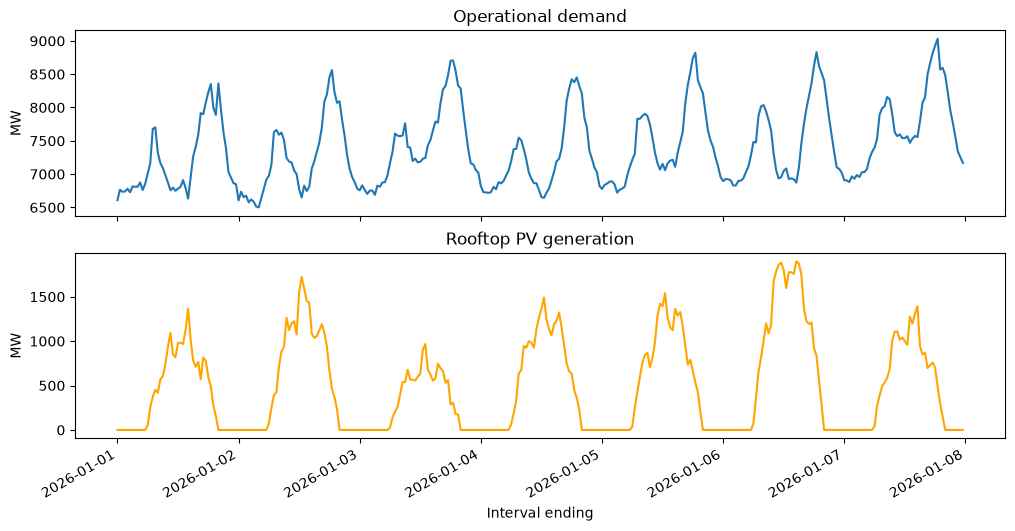

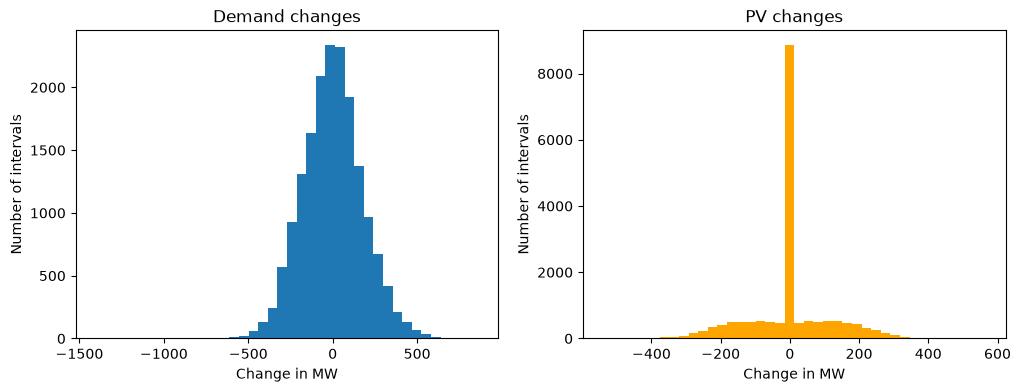

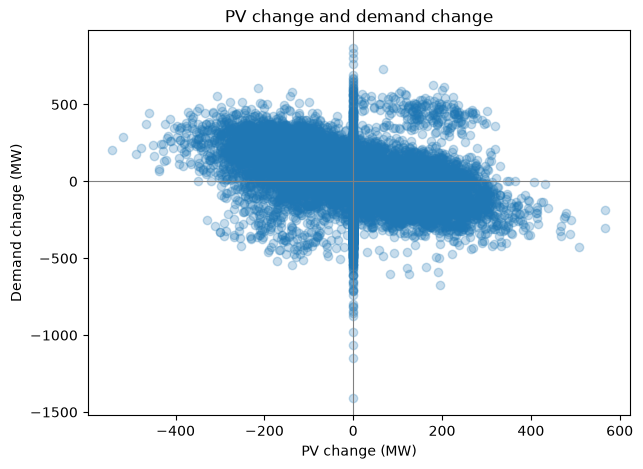

In [14]:
# Refer to Bel's existing EDA before adding more plots.
# Use training data to plot demand/PV changes and inspect their distributions.
# Plot PV change against demand change.
# Look for differences by time of day, season and weather where available.


# Plot demand and PV for the first seven days.
def plot_first_week(data):
    week = data.head(48 * 7)
    figure, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(week['INTERVAL_DATETIME'], week['OPERATIONAL_DEMAND_MW'])
    axes[0].set(title='Operational demand', ylabel='MW')
    axes[1].plot(week['INTERVAL_DATETIME'], week['ROOFTOP_PV_POWER_MW'], color='orange')
    axes[1].set(title='Rooftop PV generation', xlabel='Interval ending', ylabel='MW')
    figure.autofmt_xdate()
    plt.show()


# Show the spread of half-hourly demand and PV changes.
def plot_change_histograms(data):
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(data['DEMAND_CHANGE_MW'].dropna(), bins=40)
    axes[0].set(title='Demand changes', xlabel='Change in MW', ylabel='Number of intervals')
    axes[1].hist(data['PV_CHANGE_MW'].dropna(), bins=40, color='orange')
    axes[1].set(title='PV changes', xlabel='Change in MW', ylabel='Number of intervals')
    plt.show()


# Compare PV changes with demand changes.
def plot_change_scatter(data):
    changes = data.dropna(subset=['PV_CHANGE_MW', 'DEMAND_CHANGE_MW'])
    plt.figure(figsize=(7, 5))
    plt.scatter(changes['PV_CHANGE_MW'], changes['DEMAND_CHANGE_MW'], alpha=0.25)
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.axvline(0, color='grey', linewidth=0.8)
    plt.title('PV change and demand change')
    plt.xlabel('PV change (MW)')
    plt.ylabel('Demand change (MW)')
    plt.show()


plot_first_week(data)
plot_change_histograms(data)
plot_change_scatter(data)

## 4. Correlation / cross-correlation

In [15]:
# Calculate the correlation between current PV and demand changes.
# Compare demand change with PV changes from 30, 60, 90 and 120 minutes earlier.
# Use training data and keep missing intervals in place when shifting values.
# Treat these as exploratory checks, not a final choice of lag.

## 5. Regression models

In [16]:
# Fit the first OLS model on training data: delta_demand ~ delta_pv.
# Then add time/calendar controls and weather where available.
# Compare the PV coefficient, confidence interval and adjusted R-squared.
# Leave detailed lag selection and interactions for Week 3.

## 6. Forecasting baselines

In [17]:
# Set the forecast target to demand change over the next 30 minutes.
# Start with persistence: predict no change from current demand.
# Add a non-PV regression using demand history and available controls.

# Only use inputs available at forecast time, allowing for publication delays.
# Split by target timestamp to keep validation outcomes out of training.

## 7. PV-enhanced models

In [18]:
# Add current PV and PV change to the non-PV forecast model.
# Keep the other predictors and training rows the same for a fair comparison.
# Do not use observed PV or weather from the interval being predicted.

## 8. Evaluation

In [19]:
# Example metrics for matching, non-empty lists with no missing values.
def mae(actual, predicted):
    # Average absolute error in MW.
    errors = [abs(a - p) for a, p in zip(actual, predicted)]
    return sum(errors) / len(errors)


def rmse(actual, predicted):
    # Give larger errors more weight, then return to MW.
    squared_errors = [(a - p) ** 2 for a, p in zip(actual, predicted)]
    return (sum(squared_errors) / len(squared_errors)) ** 0.5


# Compare all forecasts on the same complete validation timestamps.
# Put MAE and RMSE for each model in a small table.
# Leave final test evaluation until model selection is finished.

## 9. Diagnostics and interpretation

In [20]:
# Plot regression residuals against fitted values and over time.
# Check for autocorrelation, changing spread and unusual observations.
# Note whether robust or HAC standard errors need investigating in Week 3.

# Summarise the PV coefficient's size and uncertainty, without claiming causation.
# Record whether PV improves validation forecasts and any remaining data issues.